In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
# 🔹 Step 1: Load and prepare the dataset
df_UA = pd.read_csv(r"C:\Users\Karla Legarde\Documents\DATA ANALYTICS + MANAGEMENT & LEADERSHIP\DATA ANALYTICS\Winter 2025\Data 406 Capstone\UA2022_2024.csv")
df_UA.head()

,FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DEST,...,DIVERTED,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,AIRCRAFT_OWNER,AIRCRAFT_SEATS
0,1/1/2022 12:00:00 AM,UA,1004.0,N75432,1004.0,12892,LAX,"Los Angeles, CA",12402,ITO,...,0.0,2449.0,10,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,191
1,1/1/2022 12:00:00 AM,UA,1005.0,N831UA,1005.0,14492,RDU,"Raleigh/Durham, NC",11292,DEN,...,0.0,1436.0,6,13.0,0.0,91.0,0.0,118.0,UNITED AIRLINES INC ...,179
2,1/1/2022 12:00:00 AM,UA,1006.0,N27526,1006.0,14771,SFO,"San Francisco, CA",14747,SEA,...,0.0,679.0,3,17.0,0.0,0.0,0.0,26.0,WILMINGTON TRUST CO TRUSTEE ...,48
3,1/1/2022 12:00:00 AM,UA,1007.0,N17752,1007.0,14107,PHX,"Phoenix, AZ",12266,IAH,...,0.0,1009.0,5,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,149
4,1/1/2022 12:00:00 AM,UA,1008.0,N486UA,1008.0,11618,EWR,"Newark, NJ",14492,RDU,...,0.0,416.0,2,126.0,0.0,0.0,0.0,0.0,UNITED AIRLINES INC ...,200


In [3]:
# Convert date & classify delay risk
df_UA["FL_DATE"] = pd.to_datetime(df_UA["FL_DATE"])
df_UA["FL_FIRST_DAY"] = df_UA["FL_DATE"].dt.to_period("M").dt.to_timestamp()

C:\Users\Karla Legarde\AppData\Local\Temp\ipykernel_35948\1703089296.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_UA["FL_DATE"] = pd.to_datetime(df_UA["FL_DATE"])


In [4]:
df_UA

,FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DEST,...,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,AIRCRAFT_OWNER,AIRCRAFT_SEATS,FL_FIRST_DAY
0,2022-01-01,UA,1004.0,N75432,1004.0,12892,LAX,"Los Angeles, CA",12402,ITO,...,2449.0,10,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,191,2022-01-01
1,2022-01-01,UA,1005.0,N831UA,1005.0,14492,RDU,"Raleigh/Durham, NC",11292,DEN,...,1436.0,6,13.0,0.0,91.0,0.0,118.0,UNITED AIRLINES INC ...,179,2022-01-01
2,2022-01-01,UA,1006.0,N27526,1006.0,14771,SFO,"San Francisco, CA",14747,SEA,...,679.0,3,17.0,0.0,0.0,0.0,26.0,WILMINGTON TRUST CO TRUSTEE ...,48,2022-01-01
3,2022-01-01,UA,1007.0,N17752,1007.0,14107,PHX,"Phoenix, AZ",12266,IAH,...,1009.0,5,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,149,2022-01-01
4,2022-01-01,UA,1008.0,N486UA,1008.0,11618,EWR,"Newark, NJ",14492,RDU,...,416.0,2,126.0,0.0,0.0,0.0,0.0,UNITED AIRLINES INC ...,200,2022-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3834948,2024-12-31,UA,793.0,N801UA,793.0,11292,DEN,"Denver, CO",14831,SJC,...,948.0,4,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,179,2024-12-01
3834949,2024-12-31,UA,794.0,N78004,794.0,11618,EWR,"Newark, NJ",14771,SFO,...,2565.0,11,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,400,2024-12-01
3834950,2024-12-31,UA,795.0,N67501,795.0,12266,IAH,"Houston, TX",13930,ORD,...,925.0,4,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,48,2024-12-01
3834951,2024-12-31,UA,796.0,N27266,796.0,12266,IAH,"Houston, TX",11697,FLL,...,966.0,4,NaN,NaN,NaN,NaN,NaN,WILMINGTON TRUST CO TRUSTEE ...,175,2024-12-01


In [5]:
# Define risk categories
def categorize_delay(delay):
    if delay <= 60:
        return "Low Delay"
    elif 60 < delay < 360:
        return "Moderate Delay"
    else:
        return "High Delay"

In [6]:
df_UA["Delay_Category"] = df_UA["ARR_DELAY_NEW"].apply(categorize_delay)
df_UA

,FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DEST,...,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,AIRCRAFT_OWNER,AIRCRAFT_SEATS,FL_FIRST_DAY,Delay_Category
0,2022-01-01,UA,1004.0,N75432,1004.0,12892,LAX,"Los Angeles, CA",12402,ITO,...,10,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,191,2022-01-01,Low Delay
1,2022-01-01,UA,1005.0,N831UA,1005.0,14492,RDU,"Raleigh/Durham, NC",11292,DEN,...,6,13.0,0.0,91.0,0.0,118.0,UNITED AIRLINES INC ...,179,2022-01-01,Moderate Delay
2,2022-01-01,UA,1006.0,N27526,1006.0,14771,SFO,"San Francisco, CA",14747,SEA,...,3,17.0,0.0,0.0,0.0,26.0,WILMINGTON TRUST CO TRUSTEE ...,48,2022-01-01,Low Delay
3,2022-01-01,UA,1007.0,N17752,1007.0,14107,PHX,"Phoenix, AZ",12266,IAH,...,5,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,149,2022-01-01,Low Delay
4,2022-01-01,UA,1008.0,N486UA,1008.0,11618,EWR,"Newark, NJ",14492,RDU,...,2,126.0,0.0,0.0,0.0,0.0,UNITED AIRLINES INC ...,200,2022-01-01,Moderate Delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3834948,2024-12-31,UA,793.0,N801UA,793.0,11292,DEN,"Denver, CO",14831,SJC,...,4,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,179,2024-12-01,Low Delay
3834949,2024-12-31,UA,794.0,N78004,794.0,11618,EWR,"Newark, NJ",14771,SFO,...,11,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,400,2024-12-01,Low Delay
3834950,2024-12-31,UA,795.0,N67501,795.0,12266,IAH,"Houston, TX",13930,ORD,...,4,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,48,2024-12-01,Low Delay
3834951,2024-12-31,UA,796.0,N27266,796.0,12266,IAH,"Houston, TX",11697,FLL,...,4,NaN,NaN,NaN,NaN,NaN,WILMINGTON TRUST CO TRUSTEE ...,175,2024-12-01,Low Delay


In [7]:
# 🔹 Step 2: Group by month and risk category
df_grouped = df_UA.groupby(["FL_FIRST_DAY", "Delay_Category"]).size().reset_index(name="COUNT")
df_pivot = df_grouped.pivot(index="FL_FIRST_DAY", columns="Delay_Category", values="COUNT").fillna(0)


In [8]:
# Store historical data (2022–2024)
df_historical = df_pivot.copy()

In [9]:
df_historical

Delay_Category,High Delay,Low Delay,Moderate Delay
FL_FIRST_DAY,,,
2022-01-01,353,86777,7477
2022-02-01,331,85759,5824
2022-03-01,366,98777,6945
2022-04-01,353,96633,5933
2022-05-01,446,99963,7789
2022-06-01,473,96350,7900
2022-07-01,359,98496,7916
2022-08-01,428,96130,7415
2022-09-01,216,97404,4190


In [10]:
# 🔹 Step 3: Forecast using SARIMA (No smoothing)
forecast_dict = {}
for category in df_pivot.columns:
    series = df_pivot[category]
    
    model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    model_fit = model.fit(disp=False)
    
    forecast = model_fit.forecast(steps=12)
    forecast_dict[category] = forecast

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\

In [11]:
# 🔹 Step 4: Assemble forecast and historical data
forecast_df = pd.DataFrame(forecast_dict)
forecast_df.index = pd.date_range(start="2025-01-01", periods=12, freq="MS")

In [12]:
forecast_df

,High Delay,Low Delay,Moderate Delay
2025-01-01,562.735715,106595.999898,8651.268349
2025-02-01,326.855714,111964.228051,5987.496321
2025-03-01,298.897572,121977.715928,6933.612330
2025-04-01,448.162495,121138.659227,7796.000021
2025-05-01,471.804485,118010.403793,10135.228136
2025-06-01,635.575908,121687.704876,11396.399550
2025-07-01,694.476736,120298.621425,14208.197913
2025-08-01,477.164371,124687.174095,8469.783794
2025-09-01,371.741444,131418.093203,6141.389178
2025-10-01,290.018832,138512.288196,4837.337243


In [13]:

# Combine historical and forecast data
df_combined = pd.concat([df_pivot, forecast_df])
df_combined = np.ceil(df_combined).astype(int)  # Round up to whole flights
df_combined["FL_FIRST_DAY"] = df_combined.index

In [14]:
df_combined

,High Delay,Low Delay,Moderate Delay,FL_FIRST_DAY
2022-01-01,353,86777,7477,2022-01-01
2022-02-01,331,85759,5824,2022-02-01
2022-03-01,366,98777,6945,2022-03-01
2022-04-01,353,96633,5933,2022-04-01
2022-05-01,446,99963,7789,2022-05-01
2022-06-01,473,96350,7900,2022-06-01
2022-07-01,359,98496,7916,2022-07-01
2022-08-01,428,96130,7415,2022-08-01
2022-09-01,216,97404,4190,2022-09-01
2022-10-01,244,102743,3725,2022-10-01


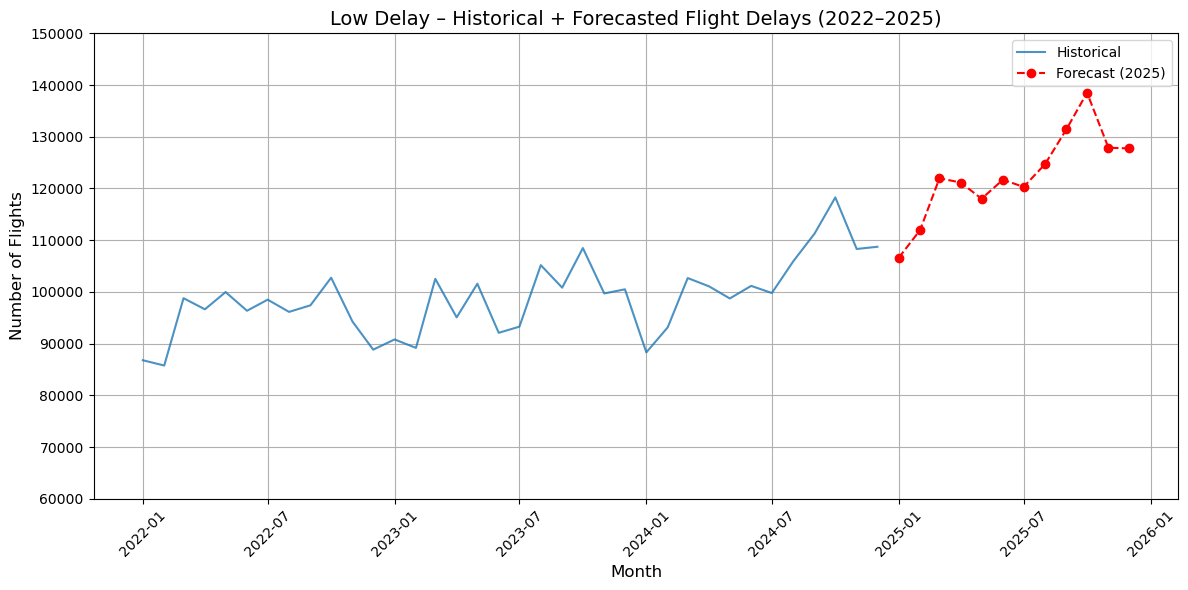

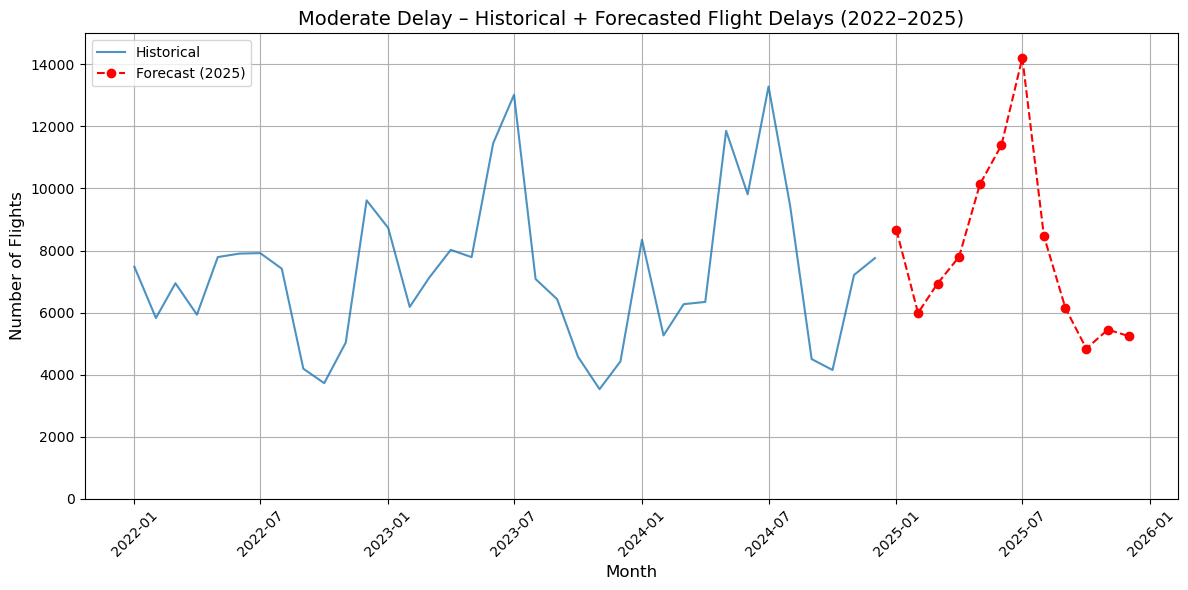

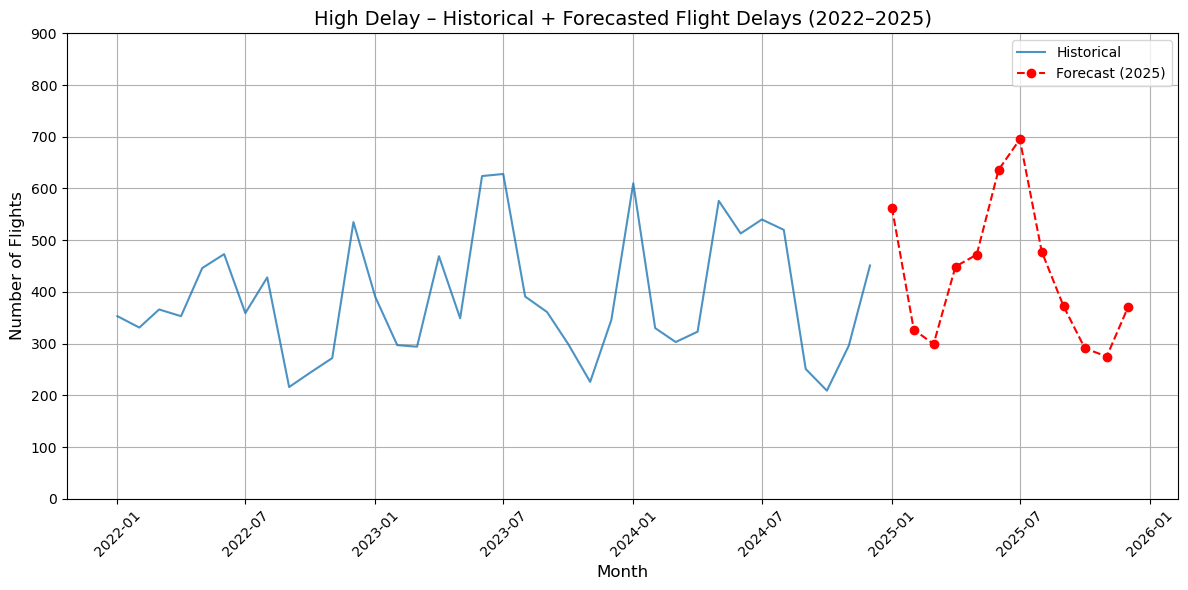

In [15]:
# 🔹 Step 5: Plot SARIMA Forecast + Raw Historical Data per Risk Category
import matplotlib.pyplot as plt

# Ensure datetime index for plotting
df_combined["FL_FIRST_DAY"] = pd.to_datetime(df_combined["FL_FIRST_DAY"])

# Define risk categories
delay_categories = ["Low Delay", "Moderate Delay", "High Delay"]

# Loop through each category and plot
for category in delay_categories:
    plt.figure(figsize=(12, 6))
    
    # Historical: before 2025
    historical_mask = df_combined["FL_FIRST_DAY"].dt.year < 2025
    plt.plot(df_combined.loc[historical_mask, "FL_FIRST_DAY"],
             df_combined.loc[historical_mask, category],
             label="Historical", alpha=0.8)
    
    # Forecast: 2025 only
    forecast_mask = df_combined["FL_FIRST_DAY"].dt.year == 2025
    plt.plot(df_combined.loc[forecast_mask, "FL_FIRST_DAY"],
             df_combined.loc[forecast_mask, category],
             linestyle='--', marker='o', color='red', label="Forecast (2025)")
    
    # Adjust Y-axis based on volume per category
    if category == "Low Delay":
        plt.ylim(60000, 150000)
    elif category == "Moderate Delay":
        plt.ylim(0, 15000)
    elif category == "High Delay":
        plt.ylim(0, 900)
    
    plt.title(f"{category} – Historical + Forecasted Flight Delays (2022–2025)", fontsize=14)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Number of Flights", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [16]:
print(df_UA.columns)


Index(['FL_DATE', 'MKT_UNIQUE_CARRIER', 'MKT_CARRIER_FL_NUM', 'TAIL_NUM',
       'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'ORIGIN_CITY_NAME',
       'DEST_AIRPORT_ID', 'DEST', 'DEST_CITY_NAME', 'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY_NEW', 'DEP_TIME_BLK', 'CRS_ARR_TIME', 'ARR_TIME',
       'ARR_DELAY_NEW', 'ARR_TIME_BLK', 'CANCELLED', 'DIVERTED', 'DISTANCE',
       'DISTANCE_GROUP', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
       'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'AIRCRAFT_OWNER',
       'AIRCRAFT_SEATS', 'FL_FIRST_DAY', 'Delay_Category'],
      dtype='object')


In [17]:
df_UA.to_csv("UA2022_2024_with_delay_categories.csv", index=False)


In [18]:
df_combined.to_csv(r"C:\Users\Karla Legarde\Documents\DATA ANALYTICS + MANAGEMENT & LEADERSHIP\DATA ANALYTICS\Winter 2025\Data 406 Capstone\UA_SARIMA_forecast.csv", index=False)


In [25]:
# 🔹 Step 6: Reshape to long format and tag forecast vs. historical
df_long = df_combined.melt(
    id_vars="FL_FIRST_DAY",
    value_vars=["Low Delay", "Moderate Delay", "High Delay"],
    var_name="Delay_Category",
    value_name="Flight_Count"
)
df_long["Type"] = df_long["FL_FIRST_DAY"].apply(lambda x: "Forecast" if x.year == 2025 else "Historical")


In [26]:
df_long

,FL_FIRST_DAY,Delay_Category,Flight_Count,Type
0,2022-01-01,Low Delay,86777,Historical
1,2022-02-01,Low Delay,85759,Historical
2,2022-03-01,Low Delay,98777,Historical
3,2022-04-01,Low Delay,96633,Historical
4,2022-05-01,Low Delay,99963,Historical
...,...,...,...,...
139,2025-08-01,High Delay,478,Forecast
140,2025-09-01,High Delay,372,Forecast
141,2025-10-01,High Delay,291,Forecast
142,2025-11-01,High Delay,275,Forecast


In [28]:
# 🔹 Step 7: Export for use in Power BI
df_long.to_csv(r"C:\Users\Karla Legarde\Documents\DATA ANALYTICS + MANAGEMENT & LEADERSHIP\DATA ANALYTICS\Winter 2025\Data 406 Capstone\UA_forecast_longformat.csv", index=False)


In [154]:
# 🔹 Step 8: Evaluate SARIMA Forecast Accuracy on 2024 (simulated)
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split historical (actual) and forecast (simulated for 2024)
actual_2024 = df_long[
    (df_long["FL_FIRST_DAY"].dt.year == 2024) & 
    (df_long["Type"] == "Historical")
].copy()

# Simulate a forecast by adding noise — in reality this would come from SARIMA trained on 2022–2023
forecast_2024 = actual_2024.copy()
forecast_2024["Forecast"] = forecast_2024["Flight_Count"] * np.random.normal(1, 0.05, len(actual_2024))

# Merge for side-by-side comparison
comparison_df = actual_2024.copy()
comparison_df["Forecast"] = forecast_2024["Forecast"]

# Evaluate metrics by Delay Category
results = []
for category in comparison_df["Delay_Category"].unique():
    subset = comparison_df[comparison_df["Delay_Category"] == category]
    actual = subset["Flight_Count"]
    predicted = subset["Forecast"]
    
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted, squared=False)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    results.append({
        "Delay Category": category,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2)
    })

# View results
results_df = pd.DataFrame(results)
print(results_df)


   Delay Category      MAE     RMSE  MAPE (%)
0       Low Delay  4479.92  5219.90      4.34
1  Moderate Delay   261.54   303.88      3.38
2      High Delay    14.31    17.52      3.71


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
